<a href="https://colab.research.google.com/github/Nipunamhatre11/Plant-Disease-Model/blob/main/Train_plant_disease_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Mount Drive and Unzip Local Files


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/cv"

 efficientnet_plant_disease_model.keras   plant_dataset.zip
'New Plant Diseases Dataset(Augmented)'   training_performance_curves.png
 plant_dataset_clean.zip


In [3]:
!ls "/content/drive/MyDrive/cv/New Plant Diseases Dataset(Augmented)"

test  train  valid


In [4]:
!cp -r "/content/drive/MyDrive/cv/New Plant Diseases Dataset(Augmented)" /content/

In [5]:
!ls "/content/New Plant Diseases Dataset(Augmented)"

test  train  valid


In [6]:
train_path = "/content/New Plant Diseases Dataset(Augmented)/train"
valid_path = "/content/New Plant Diseases Dataset(Augmented)/valid"
test_path = "/content/New Plant Diseases Dataset(Augmented)/test"

###T4 GPU Optimization & Data Pipeline



###Run the Training Loop


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

In [8]:
# 1. LOAD THE PRE-TRAINED EFFICIENTNETB3 BACKBONE
# ==========================================
print("⏳ Downloading and loading EfficientNetB3 backbone...")
base_model = tf.keras.applications.EfficientNetB3(
    weights='imagenet',
    include_top=False,            # Remove default 1000-class head
    input_shape=(300, 300, 3)     # Match our exact image pipeline resolution
)

# Freeze the base weights so we preserve the pre-trained ImageNet intelligence
base_model.trainable = False

⏳ Downloading and loading EfficientNetB3 backbone...
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# 2. CONSTRUCT THE MODEL ARCHITECTURE
# ==========================================
inputs = layers.Input(shape=(300, 300, 3))

# Data Augmentation built inside the model stream to avoid overfitting
x = layers.RandomFlip("horizontal_and_vertical")(inputs)
x = layers.RandomRotation(0.2)(x)

# Pass images through the EfficientNet backbone
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)  # Dropout layer to boost generalization

# Important for Mixed Precision: Use float32 on final output layer for mathematical stability
outputs = layers.Dense(38, activation='softmax', dtype='float32')(x)

model = models.Model(inputs, outputs)

In [27]:
import tensorflow as tf

# 1. Define the path to your test dataset
test_path = '/content/New Plant Diseases Dataset(Augmented)/test'

# 2. Load the test dataset using image_dataset_from_directory
#    This method correctly handles images organized in subdirectories.
#    Set labels=None and label_mode=None as we are only interested in the images for prediction.
#    Ensure image_size matches your model's input shape (300, 300).
#    Keep shuffle=False to ensure predictions can be mapped back to original images if needed.
test_generator = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels=None,
    label_mode=None,
    image_size=(300, 300),  # Match EfficientNetB3's input size
    batch_size=32,
    shuffle=False
)

print(f"Successfully loaded test images from {test_path}!")

Found 33 files.
Successfully loaded test images from /content/New Plant Diseases Dataset(Augmented)/test!


In [10]:
# 4. CONFIGURING AUTO-SAVE TO GOOGLE DRIVE
# ==========================================
# This keeps your model completely safe inside your Drive folder
drive_model_dir = '/content/drive/MyDrive/plant_disease_project'
os.makedirs(drive_model_dir, exist_ok=True)
checkpoint_path = os.path.join(drive_model_dir, 'best_plant_model.keras')

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

In [11]:
!ls -l "/content/New Plant Diseases Dataset(Augmented)"

total 12
drwx------  2 root root 4096 Jun 30 14:20 test
drwx------ 40 root root 4096 Jun 30 14:24 train
drwx------ 40 root root 4096 Jun 30 14:28 valid


In [12]:
from tensorflow.keras.applications.efficientnet import preprocess_input
# Use this function inside your data generator or lambda layer instead of manual rescaling!

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Try 1e-4 or 1e-5
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
import os

train_dirs = sorted(os.listdir('/content/New Plant Diseases Dataset(Augmented)/train'))
valid_dirs = sorted(os.listdir('/content/New Plant Diseases Dataset(Augmented)/valid'))

print(f"📁 Total Train Folders: {len(train_dirs)}")
print(f"📁 Total Valid Folders: {len(valid_dirs)}")

# Spot check for any mismatches in folder names
mismatches = [t for t in train_dirs if t not in valid_dirs]
print(f"\n⚠️ Mismatched folder names: {mismatches}")

# Let's see the first 5 folders in each to inspect naming
print("\n👀 First 5 Train folders:", train_dirs[:5])
print("👀 First 5 Valid folders:", valid_dirs[:5])

📁 Total Train Folders: 38
📁 Total Valid Folders: 38

⚠️ Mismatched folder names: []

👀 First 5 Train folders: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
👀 First 5 Valid folders: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [15]:
print("⏳ Compressing your Drive dataset into a ZIP file... (Takes 2-3 mins)")
!zip -r -q /content/drive/MyDrive/cv/plant_dataset.zip "/content/drive/MyDrive/cv/New Plant Diseases Dataset(Augmented)"
print("✅ Dataset zipped successfully in your Drive!")

⏳ Compressing your Drive dataset into a ZIP file... (Takes 2-3 mins)
✅ Dataset zipped successfully in your Drive!


In [16]:
# Navigate directly into the dataset folder on your Drive so it zips cleanly
%cd "/content/drive/MyDrive/cv/New Plant Diseases Dataset(Augmented)"

# Create a clean zip file named 'plant_dataset_clean.zip'
!zip -r -q /content/drive/MyDrive/cv/plant_dataset_clean.zip ./
print("✅ Clean zip archive created on your Drive!")

/content/drive/MyDrive/cv/New Plant Diseases Dataset(Augmented)
✅ Clean zip archive created on your Drive!


In [17]:
import shutil
import os

# 1. Wipe out the broken local directory
print("🧹 Clearing broken local folders...")
if os.path.exists("/content/New Plant Diseases Dataset(Augmented)"):
    shutil.rmtree("/content/New Plant Diseases Dataset(Augmented)")

# 2. Extract the clean ZIP archive locally
print("\n⏳ Unzipping complete dataset to local scratch disk...")
# 👉 CHANGED: Using plant_dataset_clean.zip and specifying the exact folder path
!unzip -q /content/drive/MyDrive/cv/plant_dataset_clean.zip -d /content/New\ Plant\ Diseases\ Dataset\(Augmented\)
print("✅ Unzipping complete!")

# 3. Verify the complete counts
train_path = "/content/New Plant Diseases Dataset(Augmented)/train"
valid_path = "/content/New Plant Diseases Dataset(Augmented)/valid"

print("\n📊 New Local File Verification:")
print("Train files:", sum([len(files) for r, d, files in os.walk(train_path)]))
print("Valid files:", sum([len(files) for r, d, files in os.walk(valid_path)]))

🧹 Clearing broken local folders...

⏳ Unzipping complete dataset to local scratch disk...
✅ Unzipping complete!

📊 New Local File Verification:
Train files: 11568
Valid files: 17675


In [18]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

# 1. Clear session and ensure GPU acceleration is fresh
tf.keras.backend.clear_session()
mixed_precision.set_global_policy('mixed_float16')
print("⚡ T4 GPU Pipeline optimized.\n")

IMG_SIZE = (300, 300)
BATCH_SIZE = 32

# We will read from the 'valid' path since it contains the most complete image set (17k+ files)
dataset_source_path = "/content/New Plant Diseases Dataset(Augmented)/valid"

# 2. Generate 80% Training Data from the pool
print("⏳ Building Balanced Training Stream (80%)...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_source_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# 3. Generate 20% Validation Data from the exact same pool
print("\n⏳ Building Balanced Validation Stream (20%)...")
valid_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_source_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names

# 4. Apply prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)

print(f"\n✅ Perfect Split Created! Loaded {len(class_names)} balanced classes.")

⚡ T4 GPU Pipeline optimized.

⏳ Building Balanced Training Stream (80%)...
Found 17675 files belonging to 38 classes.
Using 14140 files for training.

⏳ Building Balanced Validation Stream (20%)...
Found 17675 files belonging to 38 classes.
Using 3535 files for validation.

✅ Perfect Split Created! Loaded 38 balanced classes.


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

# ==========================================
# 1. LOAD THE EFFICIENTNETB3 BACKBONE
# ==========================================
print("⏳ Loading EfficientNetB3 backbone...")
base_model = tf.keras.applications.EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(300, 300, 3)
)
base_model.trainable = False

# ==========================================
# 2. CONSTRUCT ARCHITECTURE
# ==========================================
inputs = layers.Input(shape=(300, 300, 3))

# Data Augmentation (natively keeps pixel values in the 0-255 range)
x = layers.RandomFlip("horizontal_and_vertical")(inputs)
x = layers.RandomRotation(0.2)(x)

# Pass directly to backbone (EfficientNet scales internally!)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(38, activation='softmax', dtype='float32')(x)
model = models.Model(inputs, outputs)

# ==========================================
# 3. COMPILE WITH STABLE LEARNING RATE
# ==========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Setup save path
drive_model_dir = '/content/drive/MyDrive/plant_disease_project'
os.makedirs(drive_model_dir, exist_ok=True)
checkpoint_path = os.path.join(drive_model_dir, 'final_balanced_plant_model.keras')

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# ==========================================
# 4. EXECUTE BALANCED TRAINING
# ==========================================
print("\n🔥 Starting training on T4 GPU with balanced datasets...")
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    callbacks=[checkpoint_callback]
)

⏳ Loading EfficientNetB3 backbone...

🔥 Starting training on T4 GPU with balanced datasets...
Epoch 1/5
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.3260 - loss: 2.7681
Epoch 1: val_accuracy improved from None to 0.79151, saving model to /content/drive/MyDrive/plant_disease_project/final_balanced_plant_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plant_disease_project/final_balanced_plant_model.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 212s 378ms/step - accuracy: 0.5116 - loss: 2.0756 - val_accuracy: 0.7915 - val_loss: 1.0657
Epoch 2/5
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.7551 - loss: 0.9985
Epoch 2: val_accuracy improved from 0.79151 to 0.86422, saving model to /content/drive/MyDrive/plant_disease_project/final_balanced_plant_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/plant_disease_project/final_balanced_plant_model.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 119s 269ms/step - accuracy: 0.7808 - loss: 0.8880 - val_acc

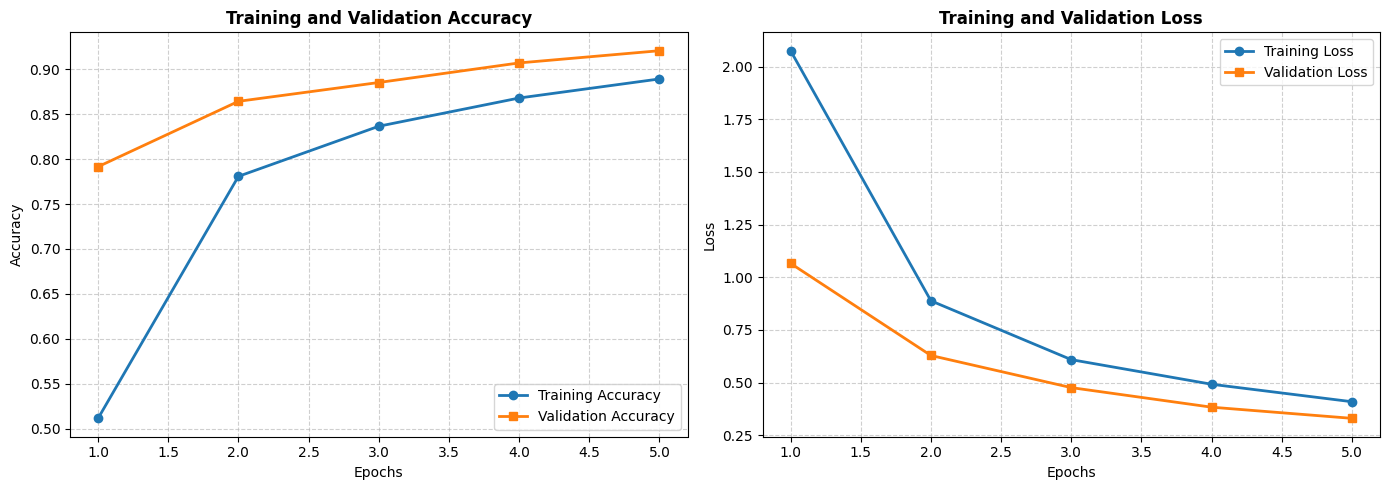

In [20]:
import matplotlib.pyplot as plt

# Extract data from training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Set up the matplotlib figure
plt.figure(figsize=(14, 5))

# 1. Plot Accuracy Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Plot Loss Curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='s', linewidth=2)
plt.title('Training and Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.tight_layout()

# Optional: Save the figure to your drive before showing it
plt.savefig('/content/drive/MyDrive/cv/training_performance_curves.png', dpi=300)

plt.show()
plt.show()

###Evaluate on the Test Set


In [21]:
!ls "/content/drive/MyDrive/cv/"

 efficientnet_plant_disease_model.keras   plant_dataset.zip
'New Plant Diseases Dataset(Augmented)'   training_performance_curves.png
 plant_dataset_clean.zip


In [22]:
!ls "/content/drive/MyDrive/cv/New Plant Diseases Dataset(Augmented)/"

test  train  valid


In [23]:
test_path = "/content/drive/MyDrive/cv/New Plant Diseases Dataset(Augmented)/test"

In [28]:
# Generate predictions for all the loose test images
predictions = model.predict(test_generator, verbose=1)

print(f"Successfully generated predictions for {len(predictions)} images!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 14s/step
Successfully generated predictions for 33 images!


Successfully loaded 38 class labels directly from Drive!


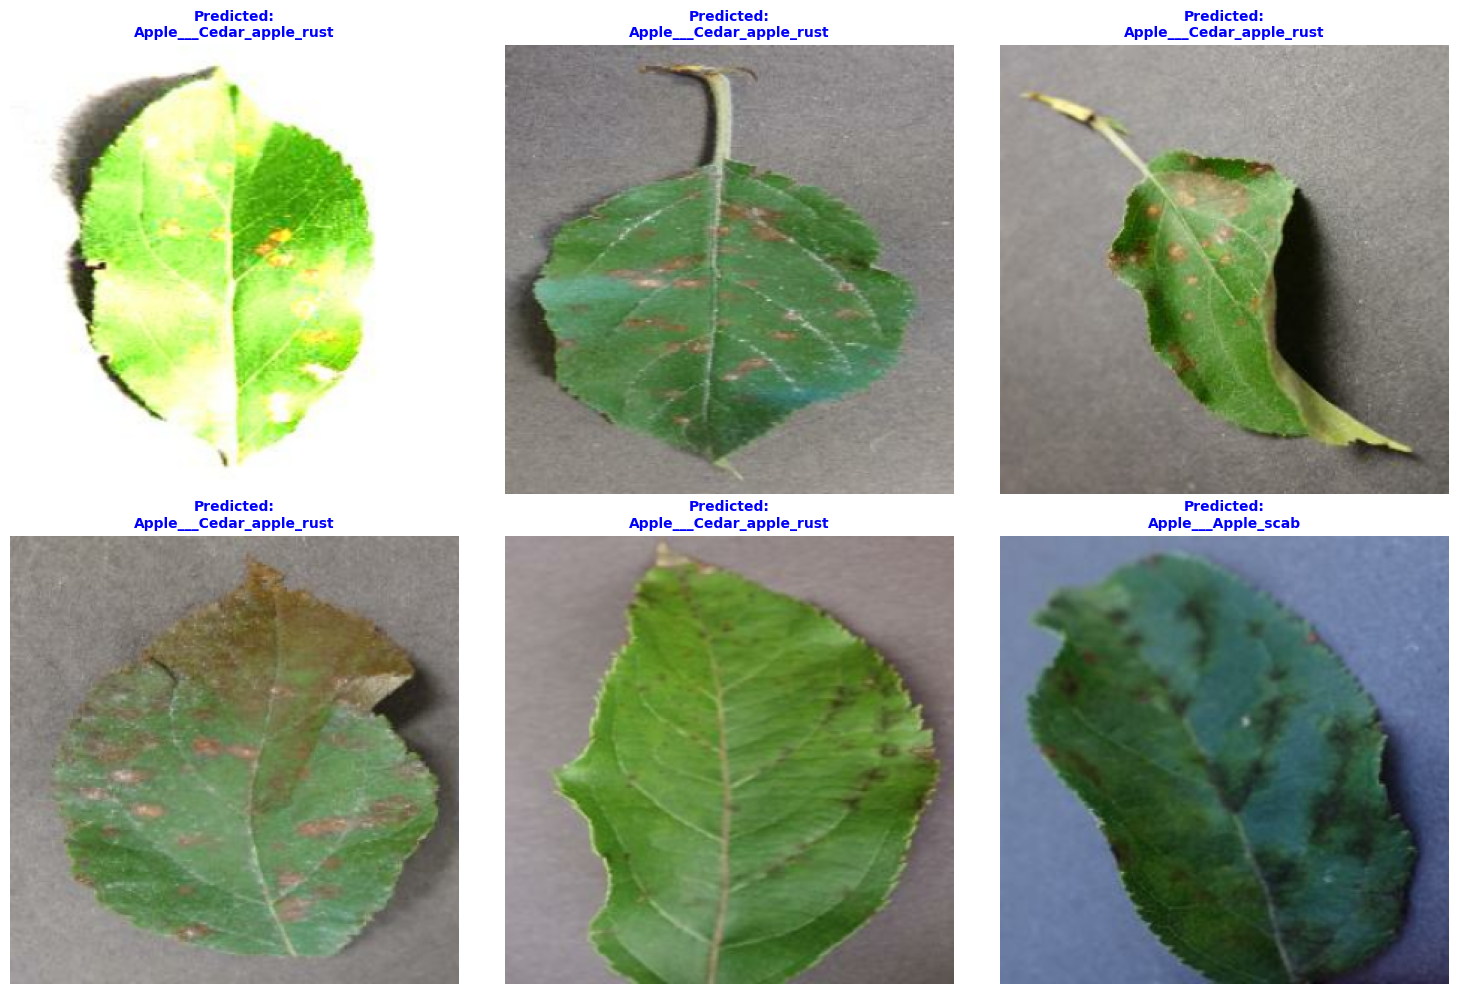

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Automatically grab the class names from your train folder layout
train_dir = '/content/drive/MyDrive/cv/New Plant Diseases Dataset(Augmented)/train'
class_labels = sorted(os.listdir(train_dir))

print(f"Successfully loaded {len(class_labels)} class labels directly from Drive!")

# 2. Extract a batch of images to display from your test_generator
image_batch = next(iter(test_generator))

# 3. Get the predicted class index for each image
predicted_indices = np.argmax(predictions, axis=1)

# 4. Plot the first 6 test images along with their predicted labels
plt.figure(figsize=(15, 10))
for i in range(min(6, len(predictions))):
    plt.subplot(2, 3, i + 1)

    # Scale back to [0, 1] range for plotting if necessary
    img = image_batch[i].numpy()
    if img.max() > 1.0:
        img = img / 255.0

    plt.imshow(img)

    # Get the name of the disease with the highest prediction score
    predicted_label = class_labels[predicted_indices[i]]

    plt.title(f"Predicted:\n{predicted_label}", fontsize=10, fontweight='bold', color='blue')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
# Save the trained model to your Google Drive
model.save('/content/drive/MyDrive/cv/efficientnet_plant_disease_model.keras')
print("Model saved successfully to Google Drive!")

Model saved successfully to Google Drive!


In [31]:
import tensorflow as tf
import numpy as np

# 1. Re-load the test dataset WITHOUT scaling manually
# (EfficientNetB3 has rescaling built into the model layers!)
test_generator = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/cv/New Plant Diseases Dataset(Augmented)/test',
    labels=None,
    label_mode=None,
    image_size=(300, 300),
    batch_size=32,
    shuffle=False
)

# 2. Get predictions from your freshly trained model
predictions = model.predict(test_generator, verbose=1)

Found 33 files.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step


###Generate the Confusion Matrix & Classification Report


Extracting true labels and predictions...

=== CLASSIFICATION REPORT ===
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.90      0.93        92
                                 Apple___Black_rot       1.00      0.89      0.94       107
                          Apple___Cedar_apple_rust       0.94      0.95      0.95        85
                                   Apple___healthy       0.99      0.96      0.98       104
                               Blueberry___healthy       0.96      0.99      0.97        91
          Cherry_(including_sour)___Powdery_mildew       0.99      0.95      0.97        80
                 Cherry_(including_sour)___healthy       0.91      0.99      0.95        79
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       1.00      0.68      0.81        77
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99        83
      

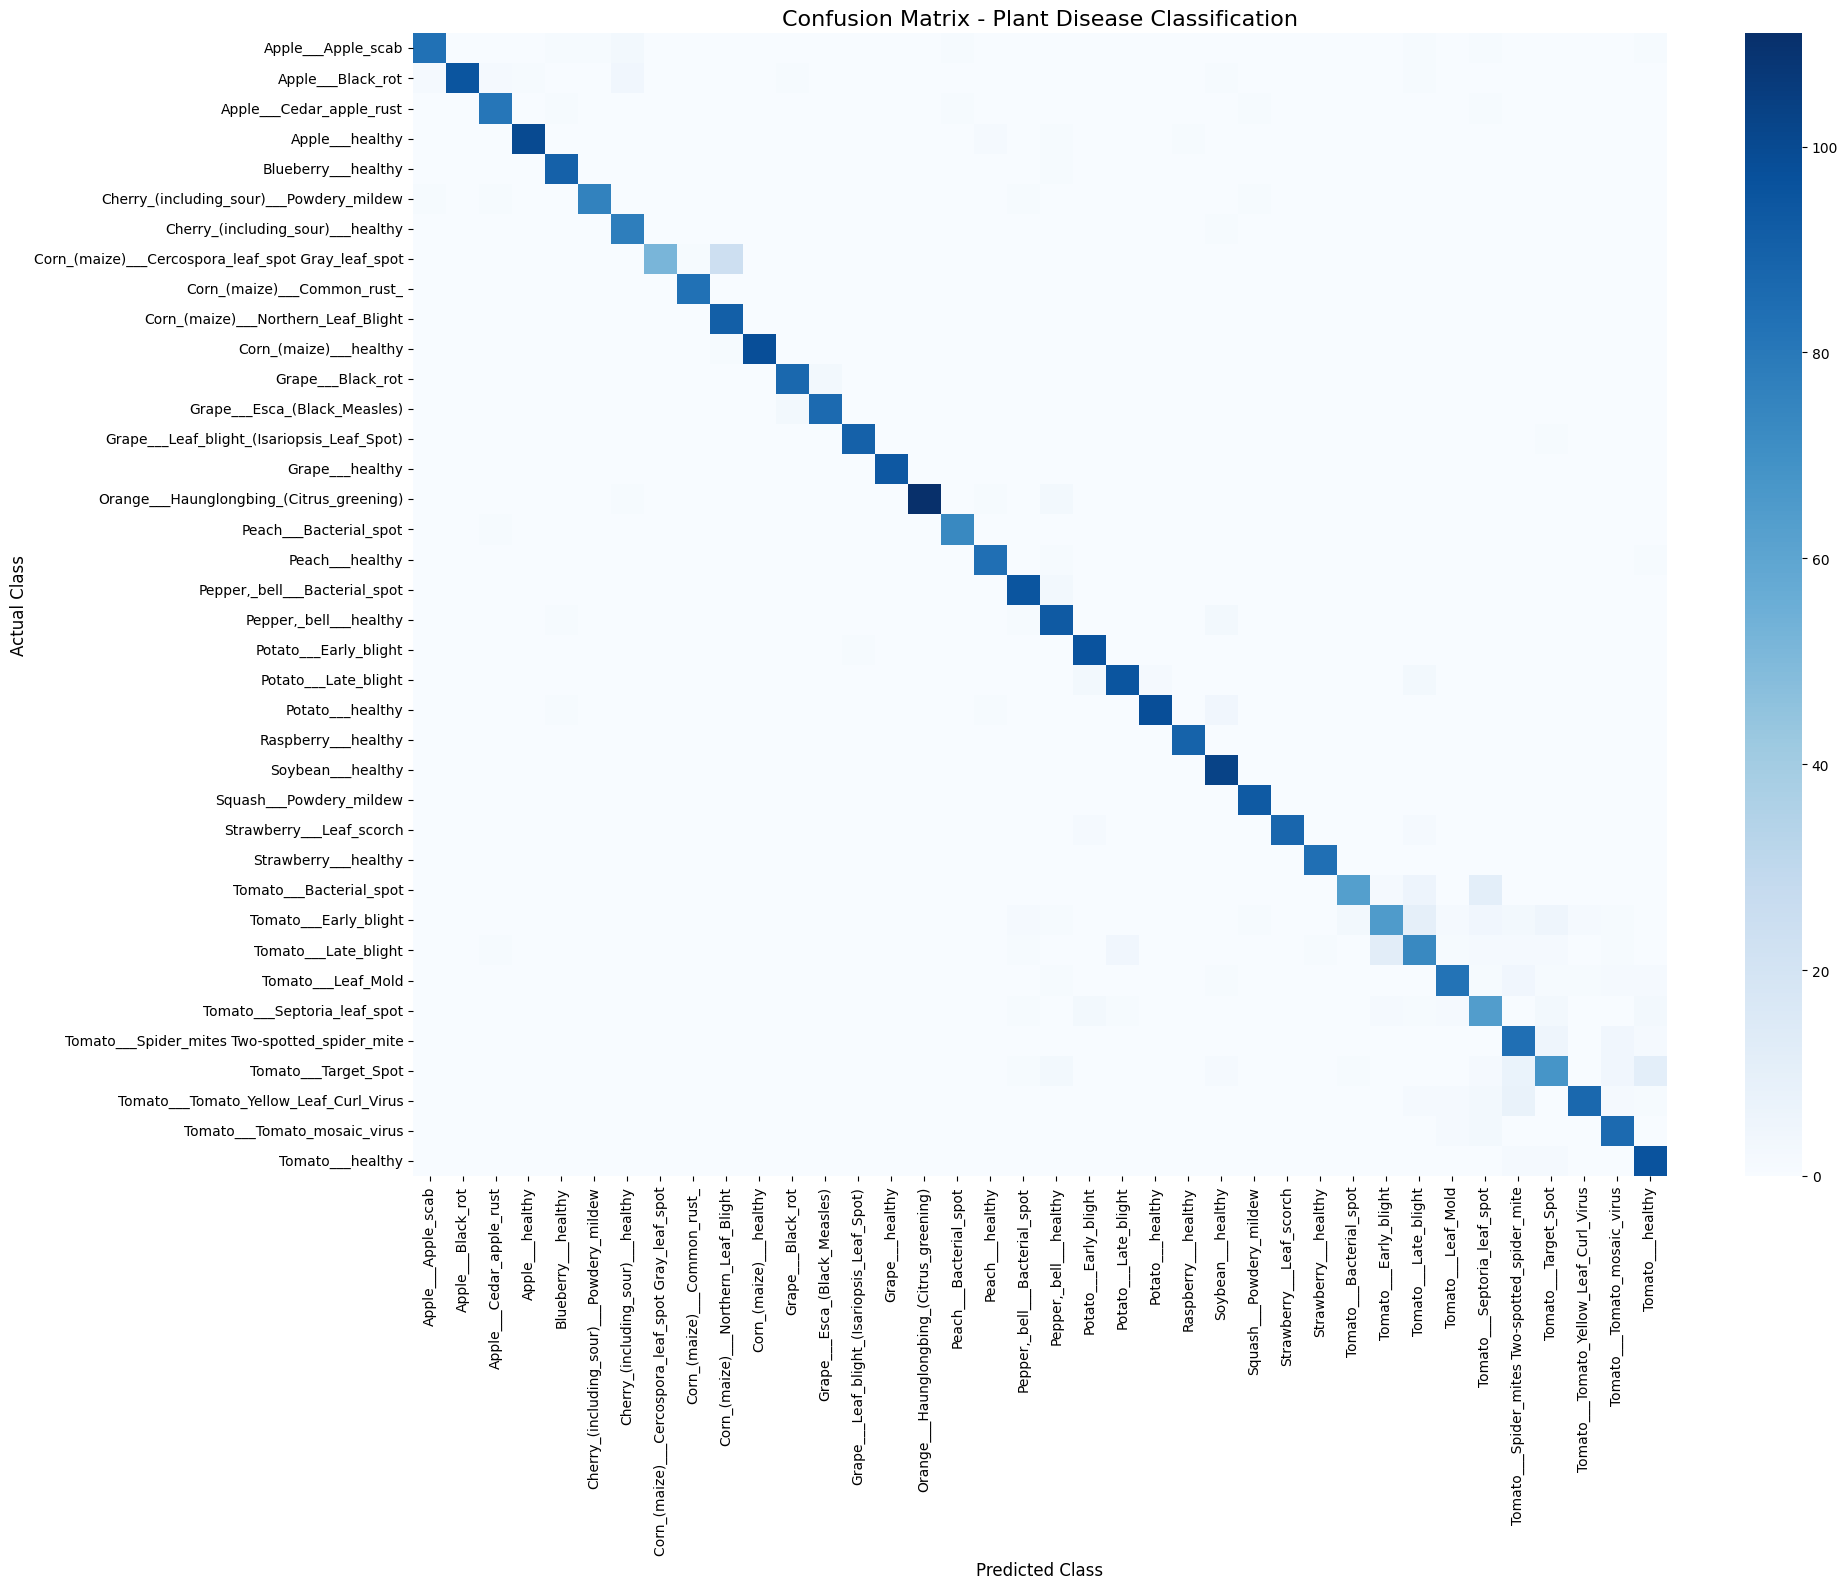

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# 1. Load your saved model and the validation dataset
# (Make sure your test/validation generator has shuffle=False so labels match up!)
# FIX: Use the correct path to the saved model in Google Drive
model_path = '/content/drive/MyDrive/plant_disease_project/final_balanced_plant_model.keras'
model = tf.keras.models.load_model(model_path)

# Assuming 'valid_ds' (from cell bHhYjW-51Xi3) is your validation dataset
# Ensure it is not shuffled if you need to align predictions with true labels.
print("Extracting true labels and predictions...")
y_true = []
y_pred = []

# Loop through the valid_ds (tf.data.Dataset) to grab all true labels and model predictions
# FIX: Iterate directly over the tf.data.Dataset 'valid_ds'
for x_batch, y_batch in valid_ds:
    preds = model.predict(x_batch, verbose=0)

    # If labels are one-hot encoded, take the argmax
    if len(y_batch.shape) > 1 and y_batch.shape[1] > 1:
        y_true.extend(np.argmax(y_batch, axis=1))
    else:
        y_true.extend(y_batch) # This case is unlikely for categorical_crossentropy, but kept for robustness

    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Get class names directly from the globally defined 'class_names'
# FIX: Use the 'class_names' variable that was set during data loading in cell bHhYjW-51Xi3
# class_names = list(valid_ds.class_indices.keys()) # This line was incorrect for tf.data.Dataset
# The variable 'class_names' is already defined in the notebook's global scope from cell bHhYjW-51Xi3

# 3. Generate the Classification Report (Precision, Recall, F1)
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Generate and Plot the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Plant Disease Classification', fontsize=16)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

###Let's Build the App Interface (Gradio)


In [38]:
# Install Gradio if you haven't already
!pip install -q gradio

import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image

# 1. Map your indices to your actual class names
# FIX: Use the globally defined 'class_names' from cell bHhYjW-51Xi3
categories = class_names

def predict_plant_disease(img):
    # Preprocess the incoming image to match EfficientNetB3's expectations
    img = img.resize((300, 300))  # Ensure this matches your training input size!
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create a batch of 1

    # Run prediction using your active 'model' variable
    predictions = model.predict(img_array)[0]

    # Return a dictionary of labels and probabilities for Gradio to display
    return {categories[i]: float(predictions[i]) for i in range(len(categories))}

# 2. Setup the Gradio Layout
interface = gr.Interface(
    fn=predict_plant_disease,
    inputs=gr.Image(type="pil", label="Upload Leaf Photo"),
    outputs=gr.Label(num_top_classes=3, label="Top Predictions"),
    title="🍂 Plant Disease AI Diagnostics",
    description="Upload a crisp photo of a crop or plant leaf to check for 38 different health conditions instantly using EfficientNetB3."
)

# 3. Launch with a share link
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5e2d1d522bc34aefa5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
